<a href="https://colab.research.google.com/github/DalpesCS50/trab_estagio4_health-insurance-claims-prediction/blob/main/Pre_processamento_health_insurance.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Pré-processamento de dados — HEALTH INSURANCE

Adaptação do notebook do professor ao problema de previsão de claim.

1. Importar bibliotecas
2. Carregar e inspecionar os dados
3. Avaliar a remoção de variáveis
4. Tratar valores ausentes
5. Explorar distribuições e transformações
6. Demonstrar escalonamento e preparar as variáveis preditoras
7. Aplicar PCA

Este notebook segue o percurso didático do original e termina nas observações sobre treino/teste.

As estatísticas e transformações aqui são calculadas sobre a base completa para exploração. Não devem ser reutilizadas como pré-processamento de uma avaliação preditiva com teste reservado.

Mediana, One-Hot Encoding e retenção de 95% da variância são escolhas desta adaptação, não etapas executadas dessa forma no original.

In [1]:
# importar bibliotecas
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA

## Dados:

Base healthinsurance.csv do projeto HEALTH INSURANCE. A variável resposta é claim; as demais colunas são candidatas a preditoras. Todas as análises deste notebook utilizam exclusivamente a base HEALTH INSURANCE.



In [2]:
# repositório dos dados
url = "https://raw.githubusercontent.com/DalpesCS50/trab_estagio4_health-insurance-claims-prediction/refs/heads/main/data/healthinsurance.csv"
df_raw = pd.read_csv(url)
df = df_raw.copy(deep=True)
display(df.head())
print("Dimensão:", df.shape)
df.info()

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7


Dimensão: (15000, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  14604 non-null  float64
 1   sex                  15000 non-null  object 
 2   weight               15000 non-null  int64  
 3   bmi                  14044 non-null  float64
 4   hereditary_diseases  15000 non-null  object 
 5   no_of_dependents     15000 non-null  int64  
 6   smoker               15000 non-null  int64  
 7   city                 15000 non-null  object 
 8   bloodpressure        15000 non-null  int64  
 9   diabetes             15000 non-null  int64  
 10  regular_ex           15000 non-null  int64  
 11  job_title            15000 non-null  object 
 12  claim                15000 non-null  float64
dtypes: float64(3), int64(6), object(4)
memory usage: 1.5+ MB


### Estrutura inicial da base HEALTH INSURANCE

A base contém 15.000 observações e 13 variáveis. A variável `claim` será utilizada como resposta, enquanto as outras 12 serão consideradas possíveis preditoras.

Foram identificados 396 valores ausentes em `age` e 956 em `bmi`. As demais variáveis não apresentam valores ausentes. As colunas `sex`, `hereditary_diseases`, `city` e `job_title` são categóricas; as demais possuem representação numérica.

Nesta etapa, os dados foram apenas carregados e inspecionados, sem tratamento ou transformação.

In [7]:
display(df[['age', 'bmi']].mean())

,0
age,39.547521
bmi,30.266413


In [8]:
display(df.loc[[0, 1, 10], ['age', 'bmi', 'claim']])
display(df.iloc[0:3, 10:])

,age,bmi,claim
0,60.0,24.3,13112.6
1,49.0,22.6,9567.0
10,51.0,33.0,44400.4


,regular_ex,job_title,claim
0,0,Actor,13112.6
1,1,Engineer,9567.0
2,1,Academician,32734.2


## Avaliação de variáveis para remoção

A avaliação de remoção considera exclusivamente as variáveis disponíveis na base HEALTH INSURANCE. Mantemos as variáveis disponíveis, inclusive smoker e job_title. A cardinalidade, isoladamente, não determina a exclusão de uma variável.

In [9]:
categorical_cols = df.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
for col in categorical_cols:
    print(f"{col}: {df[col].nunique()} categorias")
    display(df[col].value_counts())
var_remover = []
df = df.drop(columns=var_remover)

sex: 2 categorias


,count
sex,
female,7652
male,7348


hereditary_diseases: 10 categorias


,count
hereditary_diseases,
NoDisease,13998
Diabetes,148
Alzheimer,144
Obesity,136
EyeDisease,123
Cancer,109
Arthritis,96
HeartDisease,93
Epilepsy,84


city: 91 categorias


,count
city,
Nashville,302
NewOrleans,302
Charleston,298
Brimingham,298
Memphis,297
...,...
Warwick,69
Syracuse,69
Trenton,69


job_title: 35 categorias


,count
job_title,
Student,1320
HomeMakers,972
Singer,744
Actor,720
FilmMaker,714
Dancer,693
HouseKeeper,667
Manager,602
Police,412


### Análise das variáveis categóricas

Na base HEALTH INSURANCE, foram identificadas quatro variáveis categóricas: `sex`, com 2 categorias; `hereditary_diseases`, com 10; `city`, com 91; e `job_title`, com 35.

A variável `sex` apresenta frequências próximas entre as duas categorias. Em `hereditary_diseases`, predomina a categoria `NoDisease`, com 13.998 registros, correspondentes a 93,32% das observações.

Nesta etapa, todas as variáveis serão mantidas, incluindo `city` e `job_title`. Posteriormente, as quatro variáveis categóricas serão convertidas em colunas numéricas por One-Hot Encoding para permitir a aplicação do PCA.

## Valores ausentes

Utilizamos as ausências reais da base, sem acrescentar observações artificiais. O original demonstra média, mediana e moda e termina removendo linhas incompletas. Neste trabalho, escolhemos preencher age e bmi pela mediana para preservar as observações.

In [10]:
display(df.isna().sum())
display(df.isna().sum(axis=1).value_counts().sort_index())
numeric_cols = df.select_dtypes(include='number').columns
display(pd.DataFrame({'média': df[numeric_cols].mean(), 'mediana': df[numeric_cols].median()}))
display(df.mode().iloc[0])

,0
age,396
sex,0
weight,0
bmi,956
hereditary_diseases,0
no_of_dependents,0
smoker,0
city,0
bloodpressure,0
diabetes,0


,count
0,13648
1,1352


,média,mediana
age,39.547521,40.00
weight,64.909600,63.00
bmi,30.266413,29.40
no_of_dependents,1.129733,1.00
smoker,0.198133,0.00
bloodpressure,68.650133,71.00
diabetes,0.777000,1.00
regular_ex,0.224133,0.00
claim,13401.437620,9545.65


,0
age,18.0
sex,female
weight,56.0
bmi,33.3
hereditary_diseases,NoDisease
no_of_dependents,0.0
smoker,0.0
city,Nashville
bloodpressure,70.0
diabetes,1.0


### Diagnóstico dos valores ausentes

A base HEALTH INSURANCE apresenta 396 valores ausentes em `age` e 956 em `bmi`. As demais variáveis estão completas.

Das 15.000 observações, 13.648 não apresentam ausências e 1.352 possuem exatamente um valor ausente. Não há registros com ausência simultânea em `age` e `bmi`.

Foram consultadas as médias, medianas e modas para explorar possíveis formas de tratamento. Na próxima etapa, os valores ausentes serão preenchidos pelas medianas: 40 para `age` e 29,4 para `bmi`, preservando todas as observações.

In [11]:
display(df.isna().sum())
display(df.isna().sum(axis=1).value_counts().sort_index())
numeric_cols = df.select_dtypes(include='number').columns
display(pd.DataFrame({'média': df[numeric_cols].mean(), 'mediana': df[numeric_cols].median()}))
display(df.mode().iloc[0])

,0
age,396
sex,0
weight,0
bmi,956
hereditary_diseases,0
no_of_dependents,0
smoker,0
city,0
bloodpressure,0
diabetes,0


,count
0,13648
1,1352


,média,mediana
age,39.547521,40.00
weight,64.909600,63.00
bmi,30.266413,29.40
no_of_dependents,1.129733,1.00
smoker,0.198133,0.00
bloodpressure,68.650133,71.00
diabetes,0.777000,1.00
regular_ex,0.224133,0.00
claim,13401.437620,9545.65


,0
age,18.0
sex,female
weight,56.0
bmi,33.3
hereditary_diseases,NoDisease
no_of_dependents,0.0
smoker,0.0
city,Nashville
bloodpressure,70.0
diabetes,1.0


In [12]:
medianas = df[['age', 'bmi']].median()
df[['age', 'bmi']] = df[['age', 'bmi']].fillna(medianas)
print("Medianas utilizadas:")
display(medianas)
print("Ausências após o tratamento:")
display(df.isna().sum())
assert not df.isna().any().any(), "Há ausências adicionais que precisam de tratamento."
assert len(df) == len(df_raw)

Medianas utilizadas:


,0
age,40.0
bmi,29.4


Ausências após o tratamento:


,0
age,0
sex,0
weight,0
bmi,0
hereditary_diseases,0
no_of_dependents,0
smoker,0
city,0
bloodpressure,0
diabetes,0


### Resultado do tratamento dos valores ausentes

Na base HEALTH INSURANCE, os 396 valores ausentes de `age` foram substituídos pela mediana 40,0, e os 956 valores ausentes de `bmi`, pela mediana 29,4.

Após o tratamento, nenhuma variável apresenta valores ausentes. As 15.000 observações foram preservadas, sem exclusão de linhas.

## Distribuições e estatísticas descritivas

Adaptamos os exemplos de EXPEND, INCOME e variáveis binárias do professor às colunas disponíveis no HEALTH INSURANCE.

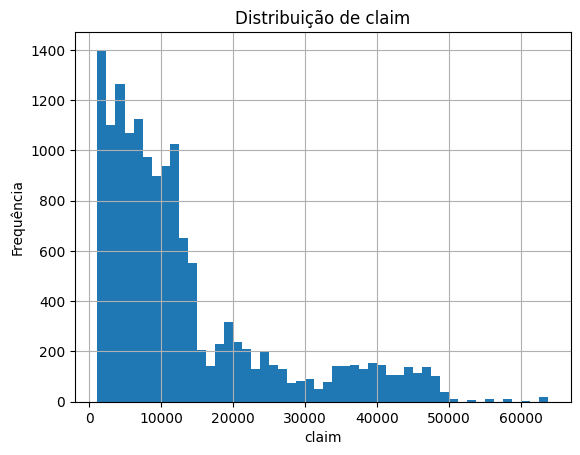

,count,mean,std,min,25%,50%,75%,max
age,15000.0,39.559467,13.829896,18.0,27.0,40.00,51.000,64.0
weight,15000.0,64.909600,13.701935,34.0,54.0,63.00,76.000,95.0
bmi,15000.0,30.211193,5.928386,16.0,25.9,29.40,34.100,53.1
no_of_dependents,15000.0,1.129733,1.228469,0.0,0.0,1.00,2.000,5.0
smoker,15000.0,0.198133,0.398606,0.0,0.0,0.00,0.000,1.0
bloodpressure,15000.0,68.650133,19.418515,0.0,64.0,71.00,80.000,122.0
diabetes,15000.0,0.777000,0.416272,0.0,1.0,1.00,1.000,1.0
regular_ex,15000.0,0.224133,0.417024,0.0,0.0,0.00,0.000,1.0
claim,15000.0,13401.437620,12148.239619,1121.9,4846.9,9545.65,16519.125,63770.4


In [13]:
df['claim'].hist(bins=50)
plt.title('Distribuição de claim')
plt.xlabel('claim')
plt.ylabel('Frequência')
plt.show()
display(df.describe().transpose())

### Distribuição de claim e estatísticas descritivas

Após o tratamento dos valores ausentes, todas as variáveis numéricas da base HEALTH INSURANCE apresentam 15.000 observações.

A variável resposta `claim` apresenta assimetria à direita, com maior concentração de observações nos valores mais baixos e uma cauda que se estende até 63.770,40. Sua média é 13.401,44, superior à mediana de 9.545,65, e o desvio-padrão é 12.148,24.

As médias de `age` e `bmi` após a imputação são, respectivamente, 39,56 e 30,21. A variável `bloodpressure` apresenta valor mínimo zero, cujo significado deverá ser verificado antes de uma eventual decisão de tratamento.

,count
sex,
female,7652
male,7348


,proportion
sex,
female,0.510133
male,0.489867


,smoker,diabetes,regular_ex
0,12028,3345,11638
1,2972,11655,3362


,smoker,diabetes,regular_ex
0,0.801867,0.223,0.775867
1,0.198133,0.777,0.224133


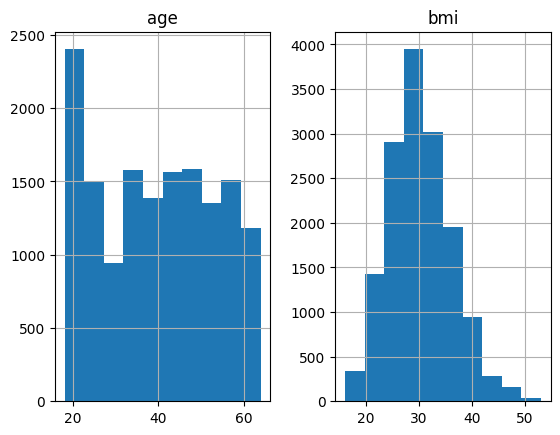

In [14]:
display(df['sex'].value_counts())
display(df['sex'].value_counts(normalize=True))
binary_cols = ['smoker', 'diabetes', 'regular_ex']
display(df[binary_cols].apply(pd.Series.value_counts))
display(df[binary_cols].apply(pd.Series.value_counts) / len(df))
df[['age', 'bmi']].hist()
plt.show()

### Frequências e distribuições de age e bmi

Na base HEALTH INSURANCE, a variável `sex` apresenta proporções próximas: 51,01% na categoria `female` e 48,99% em `male`.

A categoria 1 corresponde a 19,81% dos registros de `smoker`, 77,70% de `diabetes` e 22,41% de `regular_ex`.

As idades variam de 18 a 64 anos, com maior frequência no primeiro intervalo do histograma. A variável `bmi` apresenta maior concentração em torno de 30 e uma cauda à direita.

Os histogramas representam os dados após a imputação. Portanto, incluem os 396 valores de `age` preenchidos com 40 e os 956 valores de `bmi` preenchidos com 29,4, o que aumenta a frequência nos intervalos que contêm essas medianas.

In [15]:
display(df[['age', 'bmi', 'weight', 'claim']].corr())

,age,bmi,weight,claim
age,1.000000,0.180284,0.281542,0.298063
bmi,0.180284,1.000000,0.242398,0.196672
weight,0.281542,0.242398,1.000000,0.077716
claim,0.298063,0.196672,0.077716,1.000000


### Correlação entre variáveis numéricas e claim

Na base HEALTH INSURANCE, após a imputação dos valores ausentes, as correlações de Pearson com `claim` são positivas: aproximadamente 0,298 para `age`, 0,197 para `bmi` e 0,078 para `weight`.

Entre as variáveis analisadas, `age` apresenta a associação linear mais forte com a resposta, enquanto `weight` apresenta associação linear próxima de zero.

Esses resultados descrevem relações lineares isoladas e não demonstram causalidade. Uma correlação baixa, por si só, não justifica excluir uma variável, pois ela pode contribuir por relações não lineares ou pela interação com outras preditoras.

## Demonstração de transformação logarítmica

Como não existe INCOME, demonstramos a transformação com claim. Usamos log1p para admitir valores zero e expm1 para retornar à escala original. O resultado serve apenas à análise da distribuição; claim permanece em sua escala original e não entra no PCA.

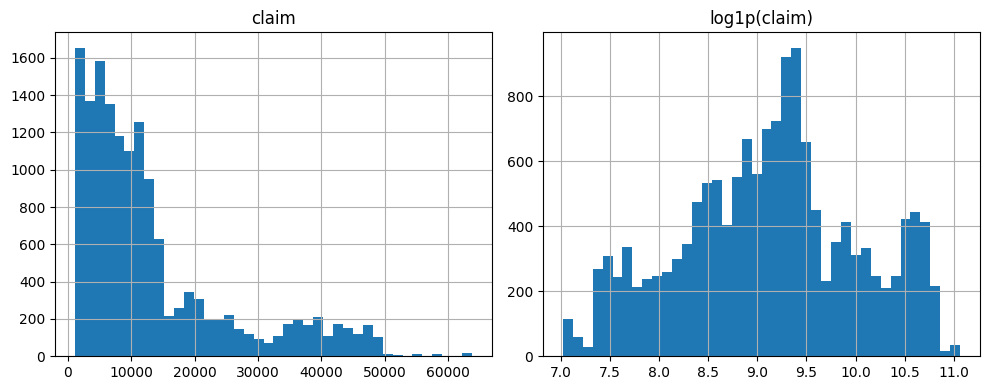

Retorno à escala original: True


In [16]:
assert (df['claim'] >= 0).all(), "A demonstração pressupõe claim não negativo."
claim_log = np.log1p(df['claim'])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
df['claim'].hist(bins=40, ax=axes[0])
axes[0].set_title('claim')
claim_log.hist(bins=40, ax=axes[1])
axes[1].set_title('log1p(claim)')
plt.tight_layout()
plt.show()
print("Retorno à escala original:", np.allclose(np.expm1(claim_log), df['claim']))

### Demonstração da transformação logarítmica de claim

Na base HEALTH INSURANCE, a transformação `log1p(claim)` comprime os valores mais altos e reduz a extensão da cauda à direita. O histograma transformado ainda apresenta vários picos; não podemos concluir que a distribuição se tornou normal.

A transformação inversa, `expm1`, recuperou os valores originais dentro da tolerância numérica, conforme o resultado `True`.

Esta etapa é demonstrativa: `claim` permanece em sua escala original como variável resposta e não será incluída no PCA.

## Escalonamento

Assim como no original, demonstramos StandardScaler e MinMaxScaler em idade e IMC. Padronizar centra e escala os dados; não garante uma distribuição normal. Os resultados da demonstração não substituem as colunas originais.

Médias: [39.55946667 30.21119333]
Escalas: [13.82943469  5.9281882 ]


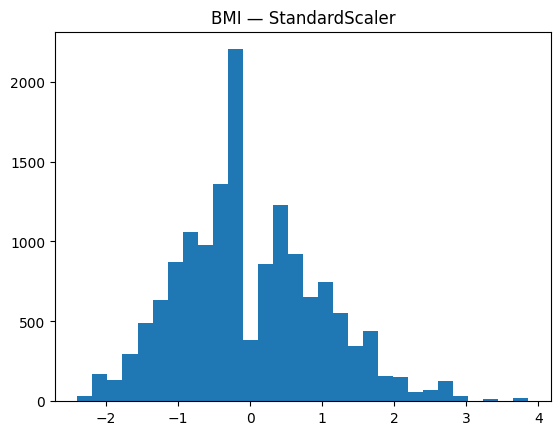

In [17]:
scaler = StandardScaler().fit(df[['age', 'bmi']])
age_bmi_scaled = scaler.transform(df[['age', 'bmi']])
print("Médias:", scaler.mean_)
print("Escalas:", scaler.scale_)
plt.hist(age_bmi_scaled[:, 1], bins=30)
plt.title('BMI — StandardScaler')
plt.show()

### Demonstração de padronização com StandardScaler

Após a imputação na base HEALTH INSURANCE, o StandardScaler utilizou as médias 39,5595 para `age` e 30,2112 para `bmi`, com escalas de 13,8294 e 5,9282, respectivamente.

A padronização subtrai a média e divide pelo desvio-padrão, produzindo variáveis com média aproximadamente zero e variância unitária. O histograma de `bmi` mantém a forma da distribuição, incluindo sua cauda à direita: a padronização não torna os dados normalmente distribuídos.

Nesta demonstração, os resultados foram armazenados separadamente, sem substituir as colunas originais de `df`.

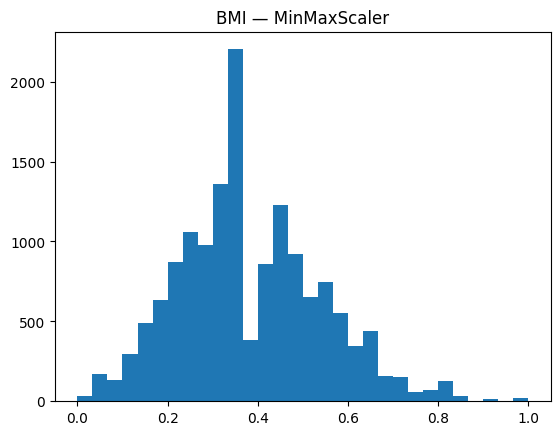

,age,sex,weight,bmi,hereditary_diseases,no_of_dependents,smoker,city,bloodpressure,diabetes,regular_ex,job_title,claim,age_norm,bmi_norm
0,60.0,male,64,24.3,NoDisease,1,0,NewYork,72,0,0,Actor,13112.6,0.913043,0.223720
1,49.0,female,75,22.6,NoDisease,1,0,Boston,78,1,1,Engineer,9567.0,0.673913,0.177898
2,32.0,female,64,17.8,Epilepsy,2,1,Phildelphia,88,1,1,Academician,32734.2,0.304348,0.048518
3,61.0,female,53,36.4,NoDisease,1,1,Pittsburg,72,1,0,Chef,48517.6,0.934783,0.549865
4,19.0,female,50,20.6,NoDisease,0,0,Buffalo,82,1,0,HomeMakers,1731.7,0.021739,0.123989


In [18]:
minmax_scaler = MinMaxScaler().fit(df[['age', 'bmi']])
age_bmi_minmax = minmax_scaler.transform(df[['age', 'bmi']])
plt.hist(age_bmi_minmax[:, 1], bins=30)
plt.title('BMI — MinMaxScaler')
plt.show()
df[['age_norm', 'bmi_norm']] = age_bmi_minmax
display(df.head())
df = df.drop(columns=['age_norm', 'bmi_norm'])

### Demonstração de escalonamento com MinMaxScaler

Na base HEALTH INSURANCE, o MinMaxScaler transformou `age` e `bmi` para o intervalo [0, 1], utilizando os valores mínimos e máximos de cada variável.

O histograma de `bmi` mantém a forma da distribuição original, com alteração apenas da escala. As colunas `age_norm` e `bmi_norm` foram adicionadas para visualizar os resultados e removidas ao final da demonstração, preservando as variáveis originais.

## Preparação de X para o PCA — adaptação ao trabalho

Separamos claim como resposta e mantemos job_title. Preservamos as escolhas do trabalho: MinMaxScaler em age e bmi, StandardScaler em weight e bloodpressure, demais variáveis numéricas na escala existente e One-Hot Encoding nas categóricas.

A codificação é necessária porque o PCA exige entradas numéricas; ela não aparece no notebook original. A combinação de escalas influencia a variância e os componentes, portanto os resultados correspondem especificamente a estas escolhas. Esta preparação é exploratória, ajustada na base completa.

In [19]:
y = df['claim'].copy()
X = df.drop(columns='claim').copy()
minmax_final = MinMaxScaler()
standard_final = StandardScaler()
X[['age', 'bmi']] = minmax_final.fit_transform(X[['age', 'bmi']])
X[['weight', 'bloodpressure']] = standard_final.fit_transform(X[['weight', 'bloodpressure']])
categorical_cols = X.select_dtypes(include=['object', 'string', 'category']).columns.tolist()
X = pd.get_dummies(X, columns=categorical_cols, drop_first=True, dtype=float)
X = X.astype(float)
assert 'claim' not in X.columns
assert np.isfinite(X.to_numpy()).all()
assert np.array_equal(y.to_numpy(), df_raw['claim'].to_numpy())
print("Dimensão de X:", X.shape)
print("Dimensão de y:", y.shape)
display(X.describe().transpose())

Dimensão de X: (15000, 142)
Dimensão de y: (15000,)


,count,mean,std,min,25%,50%,75%,max
age,15000.0,4.686841e-01,0.300650,0.000000,0.195652,0.478261,0.717391,1.000000
weight,15000.0,1.743198e-16,1.000033,-2.255932,-0.796235,-0.139372,0.809431,2.196143
bmi,15000.0,3.830510e-01,0.159795,0.000000,0.266846,0.361186,0.487871,1.000000
no_of_dependents,15000.0,1.129733e+00,1.228469,0.000000,0.000000,1.000000,2.000000,5.000000
smoker,15000.0,1.981333e-01,0.398606,0.000000,0.000000,0.000000,0.000000,1.000000
...,...,...,...,...,...,...,...,...
job_title_Police,15000.0,2.746667e-02,0.163444,0.000000,0.000000,0.000000,0.000000,1.000000
job_title_Politician,15000.0,2.466667e-02,0.155112,0.000000,0.000000,0.000000,0.000000,1.000000
job_title_Singer,15000.0,4.960000e-02,0.217124,0.000000,0.000000,0.000000,0.000000,1.000000
job_title_Student,15000.0,8.800000e-02,0.283304,0.000000,0.000000,0.000000,0.000000,1.000000


### Resultado da preparação das variáveis para o PCA

Após as transformações da base HEALTH INSURANCE, o conjunto de preditoras `X` apresenta 15.000 observações e 142 colunas. A variável resposta `claim` foi separada em `y`, com 15.000 valores, mantendo sua escala original e ficando fora do PCA.

As variáveis `age` e `bmi` foram escalonadas com MinMaxScaler, enquanto `weight` e `bloodpressure` foram padronizadas com StandardScaler. As demais preditoras numéricas permaneceram em suas escalas existentes.

As quatro variáveis categóricas, incluindo `job_title`, foram convertidas em 134 colunas indicadoras por One-Hot Encoding, com uma categoria de referência omitida por variável.

Esta preparação foi realizada sobre a base completa para a análise exploratória do PCA.

## PCA

Primeiro examinamos a variância explicada por todos os componentes, como no professor. O número de componentes será calculado para esta base, com o número de componentes e a variância explicada calculados para HEALTH INSURANCE.

array([2.44227105e-01, 1.58953081e-01, 1.48058926e-01, 3.85330887e-02,
       2.98414341e-02, 2.74203132e-02, 2.51926320e-02, 1.63789789e-02,
       1.00087919e-02, 8.92154468e-03, 7.71626453e-03, 7.62004441e-03,
       7.35100991e-03, 7.09276668e-03, 6.96171376e-03, 6.30052684e-03,
       5.56762772e-03, 4.29142194e-03, 4.15260942e-03, 4.05114300e-03,
       3.95791724e-03, 3.90536602e-03, 3.88572803e-03, 3.83755934e-03,
       3.80410612e-03, 3.77922676e-03, 3.68052964e-03, 3.52704964e-03,
       3.42890084e-03, 3.33536822e-03, 3.18801319e-03, 3.17747046e-03,
       3.15321462e-03, 3.12795051e-03, 3.09905911e-03, 3.07929025e-03,
       3.05683262e-03, 3.02894052e-03, 3.01828123e-03, 2.97507509e-03,
       2.96358265e-03, 2.95538121e-03, 2.91740761e-03, 2.90573193e-03,
       2.88451001e-03, 2.86344885e-03, 2.84307904e-03, 2.80790228e-03,
       2.80291373e-03, 2.74200061e-03, 2.69407333e-03, 2.67045409e-03,
       2.62904186e-03, 2.59391992e-03, 2.57382984e-03, 2.47173673e-03,
      

array([0.2442271 , 0.40318019, 0.55123911, 0.5897722 , 0.61961363,
       0.64703395, 0.67222658, 0.68860556, 0.69861435, 0.70753589,
       0.71525216, 0.7228722 , 0.73022321, 0.73731598, 0.74427769,
       0.75057822, 0.75614585, 0.76043727, 0.76458988, 0.76864102,
       0.77259894, 0.77650431, 0.78039003, 0.78422759, 0.7880317 ,
       0.79181093, 0.79549146, 0.79901851, 0.80244741, 0.80578277,
       0.80897079, 0.81214826, 0.81530147, 0.81842942, 0.82152848,
       0.82460777, 0.82766461, 0.83069355, 0.83371183, 0.8366869 ,
       0.83965049, 0.84260587, 0.84552327, 0.84842901, 0.85131352,
       0.85417696, 0.85702004, 0.85982795, 0.86263086, 0.86537286,
       0.86806693, 0.87073739, 0.87336643, 0.87596035, 0.87853418,
       0.88100592, 0.88344415, 0.88586929, 0.8882783 , 0.89061705,
       0.89281796, 0.89490022, 0.89697406, 0.89904028, 0.90110022,
       0.90315374, 0.90520233, 0.90724612, 0.90928817, 0.91132418,
       0.91334105, 0.91526333, 0.91707227, 0.9188776 , 0.92067

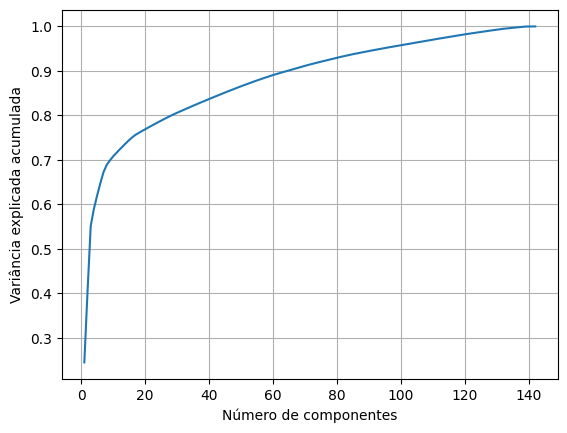

In [24]:
pca = PCA(svd_solver='full')
pca.fit(X)
display(pca.explained_variance_ratio_)
variancia_acumulada = np.cumsum(pca.explained_variance_ratio_)
display(variancia_acumulada)
plt.plot(
    np.arange(1, len(variancia_acumulada) + 1),
    variancia_acumulada
)
plt.xlabel('Número de componentes')
plt.ylabel('Variância explicada acumulada')
plt.grid()
plt.show()

### Variância explicada e escolha dos componentes principais

Na base HEALTH INSURANCE, os três primeiros componentes explicam aproximadamente 55,12% da variância total das preditoras transformadas.

Para alcançar o critério de retenção de pelo menos 95%, são necessários 94 componentes, que explicam aproximadamente 95,01% da variância. Com 93 componentes, a proporção é de 94,88%, ainda abaixo do limite escolhido.

Assim, o PCA reduzirá o conjunto de 142 preditoras transformadas para 94 componentes. Esses resultados dependem das escolhas de escalonamento e codificação adotadas e não representam a proporção de `claim` explicada pelo modelo, pois a resposta não participa do PCA.

## Escolha e aplicação dos componentes

Como critério desta adaptação, retemos pelo menos 95% da variância.

O número de componentes e a proporção alcançada são informados pela execução, sem fixar antecipadamente o valor 94. O ajuste final utiliza exclusivamente X, nunca df com a resposta.

In [21]:
n_components = int(np.searchsorted(variancia_acumulada, 0.95) + 1)
pca_final = PCA(n_components=n_components, svd_solver='full')
pca_final.fit(X)
df_pca = pca_final.transform(X)
df_pca_final = pd.DataFrame(df_pca, index=X.index,
                            columns=[f'PC_{i+1}' for i in range(n_components)])
print(f"Componentes selecionados: {n_components}")
print(f"Variância explicada: {pca_final.explained_variance_ratio_.sum():.2%}")
display(df_pca_final.head())
print("Dimensão após PCA:", df_pca.shape)
assert df_pca.shape == (len(X), n_components)

Componentes selecionados: 94
Variância explicada: 95.01%


,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6,PC_7,PC_8,PC_9,PC_10,...,PC_85,PC_86,PC_87,PC_88,PC_89,PC_90,PC_91,PC_92,PC_93,PC_94
0,-0.125824,0.102830,0.143944,0.433954,-0.578512,-0.606623,-0.136831,0.513838,-0.191080,0.033234,...,0.092294,-0.059768,-0.002600,-0.006292,-0.000217,-0.023891,0.014975,-0.024745,-0.015720,0.040415
1,0.100329,0.065666,0.855788,-0.576881,-0.204689,0.793632,-0.163666,0.008698,-0.081165,-0.023201,...,0.104438,0.067710,-0.002092,0.018269,0.015661,-0.002120,0.003760,-0.017235,-0.017832,0.050033
2,0.824538,1.063415,0.174245,-0.179140,0.787671,0.685752,-0.966883,-0.096988,-0.008802,-0.121255,...,0.081336,0.056168,0.012757,-0.009191,0.015290,-0.030327,0.044203,-0.020173,-0.060004,0.079349
3,-0.357818,0.557463,-0.573013,-0.279037,0.811278,-0.041091,-0.181454,0.474730,-0.161835,0.146408,...,0.086369,-0.105732,-0.001006,-0.010606,-0.008449,-0.012340,-0.006128,-0.015847,0.019258,0.025577
4,-1.409320,1.049082,-0.301408,-0.411599,0.084776,-0.043679,0.281340,-0.146531,0.979032,0.162731,...,-0.134179,-0.108867,-0.053152,-0.041851,-0.143293,0.775048,-0.230929,-0.424669,-0.130134,0.220318


Dimensão após PCA: (15000, 94)


### Resultado da aplicação do PCA

Na base HEALTH INSURANCE, foram selecionados 94 componentes principais, responsáveis por aproximadamente 95,01% da variância total das preditoras transformadas.

O conjunto resultante apresenta dimensão (15000, 94), preservando todas as observações e reduzindo em 48 o número de colunas em relação às 142 preditoras anteriores.

Cada componente representa uma combinação linear das preditoras. A variável resposta `claim` permanece separada em `y` e não participa da construção dos componentes.

Este resultado corresponde à análise exploratória realizada sobre a base completa.

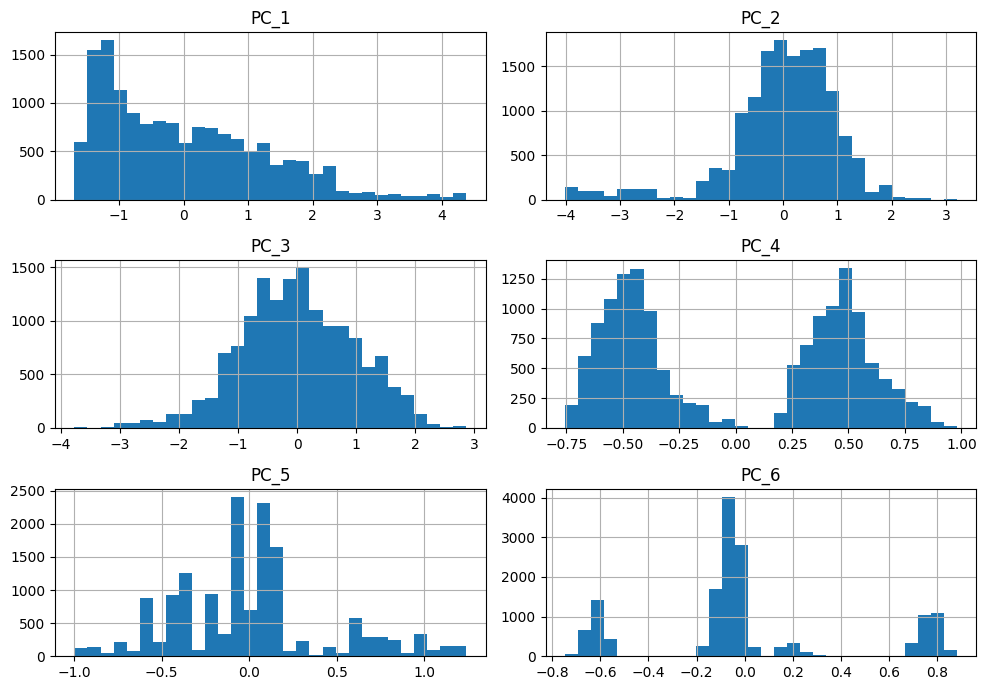

In [22]:
# Histogramas dos primeiros componentes para manter a visualização legível
df_pca_final.iloc[:, :min(6, n_components)].hist(figsize=(10, 7), bins=30)
plt.tight_layout()
plt.show()

### Distribuição dos primeiros componentes principais

Os histogramas dos seis primeiros componentes da base HEALTH INSURANCE apresentam formas distintas. `PC_1` possui uma cauda à direita, enquanto `PC_4` apresenta dois picos bem definidos. `PC_5` e `PC_6` também mostram múltiplas concentrações.

O PCA produz componentes não correlacionados entre si, mas não garante distribuições normais nem independência estatística. Os picos observados, isoladamente, não permitem identificar quais variáveis ou grupos os originaram; isso exigiria examinar os pesos das preditoras nos componentes.

Foram exibidos seis componentes para facilitar a visualização. O conjunto final mantém 94 componentes e 15.000 observações.

## Observações finais — orientação do professor

Estimar as transformações e o PCA nos dados de treinamento e, depois, aplicar as transformações ao treino e ao teste. Nunca utilizar o teste para ajustar modelos ou estimar transformações.

- Ajustar apenas no treino: pca.fit(X_treinamento).
- Aplicar em ambos: pca.transform(X_treinamento) e pca.transform(X_teste).
- A mesma regra vale para medianas, escalonamento e codificação de categorias.

O notebook termina aqui, como o original. Para uma futura avaliação preditiva, será necessário partir de df_raw, separar treino/teste antes da imputação e aprender todas as transformações somente no treino. Os componentes exploratórios deste notebook não são conjuntos de treino/teste prontos para avaliar um modelo.